In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy import optimize, signal, special
from sklearn import metrics
from sklearn.linear_model import LinearRegression

In [2]:
results = []

### Load data

In [3]:
df = pd.read_csv("cathet.csv")
df

,t,V
0,0,0.000000
1,39,0.000008
2,131,0.000027
3,184,0.000038
4,214,0.000044
...,...,...
111,6938,0.000927
112,7088,0.000943
113,7272,0.000960
114,7300,0.000963


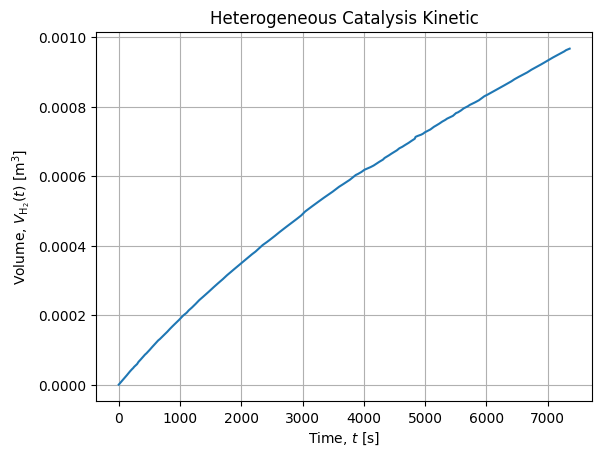

In [4]:
fig, axe = plt.subplots()
axe.plot(df["t"], df["V"])
axe.set_title("Heterogeneous Catalysis Kinetic")
axe.set_xlabel("Time, $t$ $[\mathrm{s}]$")
axe.set_ylabel("Volume, $V_\mathrm{H_2}(t)$ $[\mathrm{m^3}]$")
axe.grid()

In [5]:
R = 8.31446261815324           # J/mol.K
T0 = 292.05                    # K
p0 = 101600                    # Pa
V = 190e-6                     # m3 of isopropanol
m = 2.7677                     # g of Raney Nickel
rho = 785                      # kg/m³
M = 60.1                       # g/mol
n0 = 1000 * rho * V / M        # mol

In [6]:
n0

2.4816971713810316

In [7]:
df["xi"] = p0 * df["V"] / (R * T0)

In [8]:
df

,t,V,xi
0,0,0.000000,0.000000
1,39,0.000008,0.000339
2,131,0.000027,0.001126
3,184,0.000038,0.001603
4,214,0.000044,0.001845
...,...,...,...
111,6938,0.000927,0.038791
112,7088,0.000943,0.039439
113,7272,0.000960,0.040172
114,7300,0.000963,0.040314


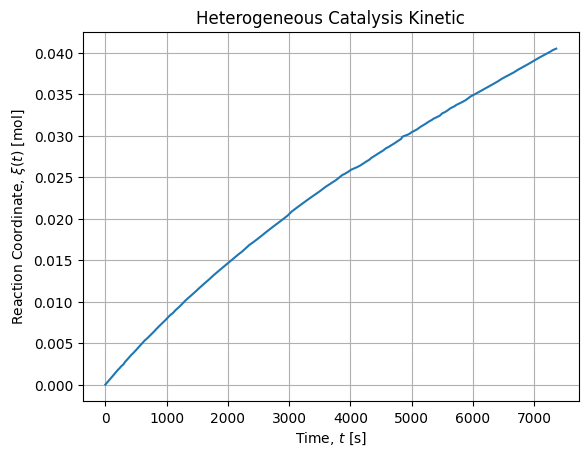

In [9]:
fig, axe = plt.subplots()
axe.plot(df["t"], df["xi"])
axe.set_title("Heterogeneous Catalysis Kinetic")
axe.set_xlabel(r"Time, $t$ $[\mathrm{s}]$")
axe.set_ylabel(r"Reaction Coordinate, $\xi(t)$ $[\mathrm{mol}]$")
axe.grid()

### NLLS w/ Analytical Solution

In [10]:
def model1(t, k1, k2):
    if k2 != 1.:
        return np.real(n0 * (1 - k2 / (1 - k2) * special.lambertw((1 - k2) / k2 * np.exp(- k1 * V * t / (n0 * k2) + (1 - k2) / k2))))
    else:
        return n0 * (1. - np.exp(- (k1 * t * V) / n0))

In [11]:
popt1, pcov1 = optimize.curve_fit(model1, df["t"], df["xi"], p0=[1e-2, 100])
popt1, pcov1

(array([4.74055853e-02, 7.73469604e+01]),
 array([[1.03016125e-08, 5.13022024e-05],
        [5.13022024e-05, 2.64738605e-01]]))

In [12]:
sp1 = np.sqrt(np.diag(pcov1))
sp1

array([1.01496860e-04, 5.14527555e-01])

In [13]:
df["xi1"] = model1(df["t"], *popt1)

In [14]:
df["eabs"] = df["xi"] - df["xi1"]
df["erel"] = df["eabs"] / df["xi1"]

In [15]:
df["eabs"].describe()

count    116.000000
mean      -0.000008
std        0.000079
min       -0.000112
25%       -0.000055
50%       -0.000030
75%        0.000002
max        0.000249
Name: eabs, dtype: float64

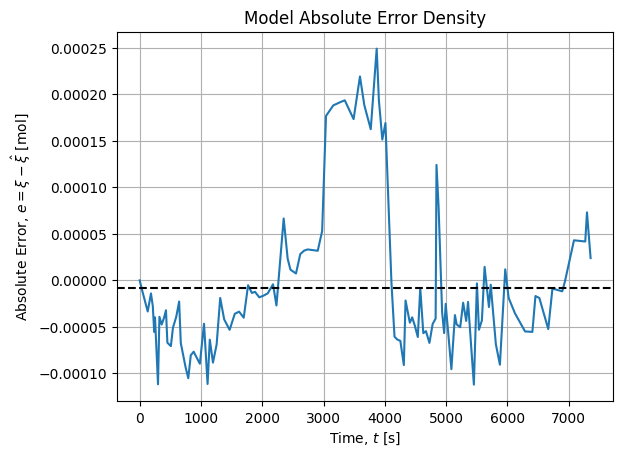

In [16]:
fig, axe = plt.subplots()
axe.plot(df["t"], df["eabs"])
axe.axhline(df["eabs"].mean(), linestyle="--", color="black")
axe.set_title("Model Absolute Error Density")
axe.set_xlabel(r"Time, $t$ $[\mathrm{s}]$")
axe.set_ylabel(r"Absolute Error, $e = \xi - \hat{\xi}$ $[\mathrm{mol}]$")
axe.grid()

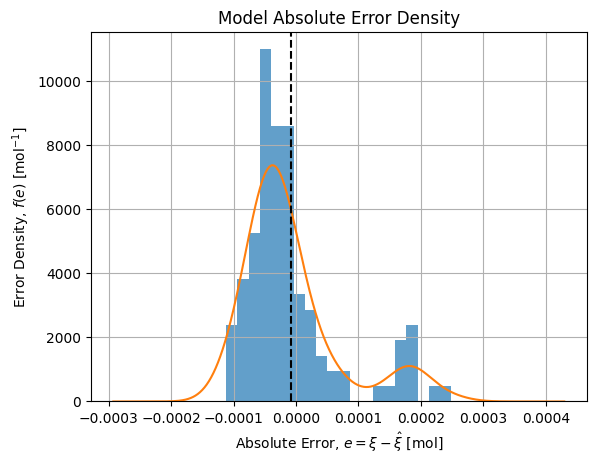

In [17]:
axe = df["eabs"].plot(kind="hist", alpha=0.7, bins=20, density=1)
df["eabs"].plot(kind="kde", ax=axe)
axe.axvline(df["eabs"].mean(), linestyle="--", color="black")
axe.set_title("Model Absolute Error Density")
axe.set_xlabel(r"Absolute Error, $e = \xi - \hat{\xi}$ $[\mathrm{mol}]$")
axe.set_ylabel(r"Error Density, $f(e)$ $[\mathrm{mol^{-1}}]$")
axe.grid()

In [18]:
df2 = df.query("eabs < 0.0001")
df2 = df.query("(t <= 2000) | ((t >= 4200) & (t <= 5500))")

In [19]:
popt2, pcov2 = optimize.curve_fit(model1, df2["t"], df2["xi"])
popt2, pcov2

(array([4.68948251e-02, 7.51219010e+01]),
 array([[5.51735133e-09, 2.92139533e-05],
        [2.92139533e-05, 1.61266740e-01]]))

In [20]:
df2["xi2"] = model1(df2["t"], *popt2)

/tmp/ipykernel_5120/2415204635.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df2["xi2"] = model1(df2["t"], *popt2)


In [21]:
df2["eabs2"] = df2["xi"] - df2["xi2"]

/tmp/ipykernel_5120/4155900396.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df2["eabs2"] = df2["xi"] - df2["xi2"]


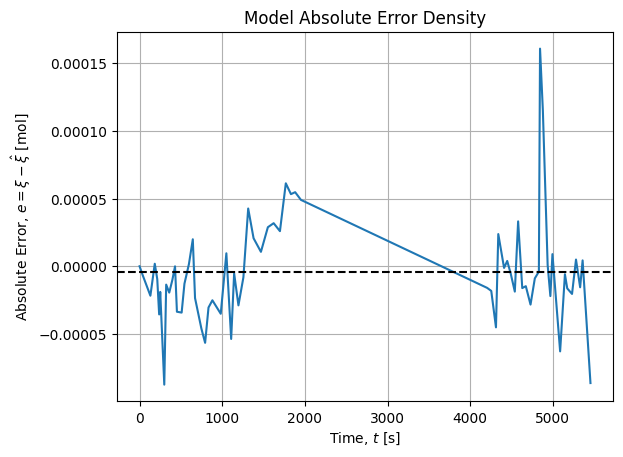

In [22]:
fig, axe = plt.subplots()
axe.plot(df2["t"], df2["eabs2"])
axe.axhline(df2["eabs2"].mean(), linestyle="--", color="black")
axe.set_title("Model Absolute Error Density")
axe.set_xlabel(r"Time, $t$ $[\mathrm{s}]$")
axe.set_ylabel(r"Absolute Error, $e = \xi - \hat{\xi}$ $[\mathrm{mol}]$")
axe.grid()

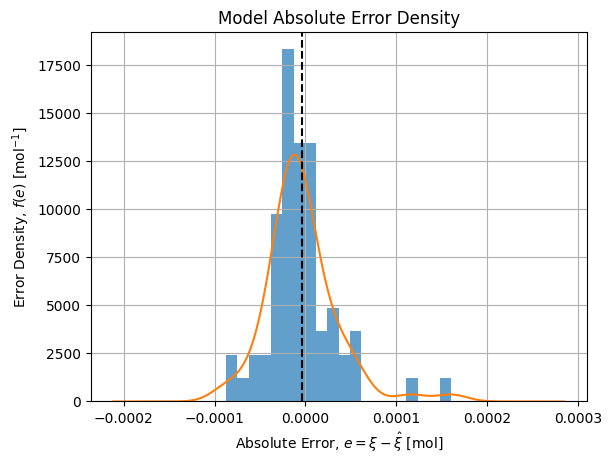

In [23]:
axe = df2["eabs2"].plot(kind="hist", alpha=0.7, bins=20, density=1)
df2["eabs2"].plot(kind="kde", ax=axe)
axe.axvline(df2["eabs2"].mean(), linestyle="--", color="black")
axe.set_title("Model Absolute Error Density")
axe.set_xlabel(r"Absolute Error, $e = \xi - \hat{\xi}$ $[\mathrm{mol}]$")
axe.set_ylabel(r"Error Density, $f(e)$ $[\mathrm{mol^{-1}}]$")
axe.grid()